# Functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Optional, Any, List

BASE_PATH = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/"

def load_and_concat(data_info: pd.DataFrame) -> pd.DataFrame:
    tables = []
    meta_cols = [c for c in data_info.columns if c != "path"]

    for _, row in data_info.iterrows():
        models = {"pix2pix":"Pix2Pix","cyclegan":"CycleGAN","cut":"CUT"}
        # load data
        df = pd.read_csv(BASE_PATH + row["path"])
        try:
            df["bodyregion"] = df["file_name"].str.split("_").str[0]
        except:
            df["bodyregion"] = df["volume_id"].str.split("_").str[0]
        df["model"] = models[row["path"].split("_")[0]]

        # drop missing values and display warning if more than 5% of data
        old_len = len(df)
        df = df.dropna()
        new_len = len(df)
        dropped_rows = old_len - new_len
        if dropped_rows/old_len > 0.05:
            folder = row["path"].split("/")[0]
            print(f"{folder}: dropping {round(dropped_rows/old_len, 4)*100}% of rows ({dropped_rows} slices) due to missing values")

        # for full-body, filter for the respective body region
        if row["region_or_fullbody"] == "Fullbody":
            assert len(df["bodyregion"].unique()) == 5, f"Not enough bodyregions in testing output for {row['path']}"
        else:
            assert len(df["bodyregion"].unique()) == 1, f"Too many bodyregions in testing output for {row['path']}"

        # attach metadata columns
        for col in meta_cols:
            df[col] = row[col]

        # reorder: metadata first, then CSV columns
        df = df[meta_cols + [c for c in df.columns if c not in meta_cols]]

        tables.append(df)

    return pd.concat(tables, ignore_index=True)

def plot_grouped_boxplots(
    df: pd.DataFrame,
    filter_column: str,
    filter_value: Any,
    metric: str,
    groups: List[str],
    *,
    figsize=(12, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if filter_column not in df.columns:
        raise KeyError(f"filter_column={filter_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df[df[filter_column] == filter_value].copy()
    dff = dff.dropna(subset=[metric])
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")
    
    # --- Uniqueness / aggregation warning ---
    base_check_cols = ["bodyregion", "model", "region_or_fullbody", "preprocessing"]
    check_cols = [c for c in base_check_cols if c not in groups]
    n_combos = dff[check_cols].drop_duplicates().shape[0]
    assert n_combos == 1, f"Values are aggregated across multiple combinations of {check_cols} (found {n_combos} unique combination(s) in the filtered data)."

    fig, ax = plt.subplots(figsize=figsize)
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))

        data = [dff.loc[dff[g1] == k, metric].values for k in order1]
        bp = ax.boxplot(
            data,
            labels=order1,
            showfliers=showfliers,
            patch_artist=True,
            medianprops={"color": "black"},
        )
        # Use first default color as background for all boxes
        for box in bp["boxes"]:
            box.set_facecolor(default_color0)

        ax.set_xlabel(g1)

    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))

        data = []
        positions = []
        tick_positions = []
        tick_labels = []

        colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
        legend_handles = [
            Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2
        ]

        gap_within = 1.0
        gap_between = 1.0
        width = 0.7

        pos = 1.0
        for a in order1:
            start = pos
            for b in order2:
                vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                data.append(vals)
                positions.append(pos)
                pos += gap_within

            end = pos - gap_within
            tick_positions.append((start + end) / 2.0)
            tick_labels.append(str(a))
            pos += gap_between

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops={"color": "black"},
        )

        for i, box in enumerate(bp["boxes"]):
            b = order2[i % len(order2)]
            box.set_facecolor(colors[b])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel(g1)

        # Legend outside on the right
        ax.legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else g2),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} | {filter_column}={filter_value}")
    ax.grid(True, axis="y", alpha=0.3)

    # Make room for the outside legend (only matters when groups==2, harmless otherwise)
    plt.tight_layout(rect=(0, 0, 0.85, 1))
    plt.show()


def plot_metric_with_subplots(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    """
    Create a single figure with subplots for each unique value in subplot_column.
    All subplots share the same y-axis scale and are arranged horizontally.
    
    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE":"↓ MAE ↓", "MSE":"↓ MSE ↓", "PSNR":"↑ PSNR ↑", "SSIM":"↑ SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    n_subplots = len(subplot_values)

    fig, axes = plt.subplots(
        1, n_subplots,
        figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
        sharey=True,
    )
    if n_subplots == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values)):
        sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.set_xlabel(g1)

        ax.set_title(str(subplot_val))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_metric_with_subplots_incl_total(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 6),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    """
    Create a single figure with subplots for each unique value in subplot_column,
    plus an additional final subplot "Total" that aggregates across all subplot values.

    All subplots share the same y-axis scale and are arranged horizontally.

    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
        The "Total" subplot ignores this split and uses all rows.
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE": "↓ MAE ↓", "MSE": "↓ MSE ↓", "PSNR": "↑ PSNR ↑", "SSIM": "↑ SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    subplot_values_incl_total = subplot_values + ["Total"]
    n_subplots = len(subplot_values_incl_total)

    fig, axes = plt.subplots(
        1,
        n_subplots,
        figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
        sharey=True,
    )
    if n_subplots == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values_incl_total)):
        region_titles = {"AB":"Abdomen","TH":"Thorax","HN":"Head-Neck","Total":"TOTAL","brain":"Brain","pelvis":"Pelvis"}
        if subplot_val == "Total":
            sub_df = dff
        else:
            sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            # Colors keyed by g2, consistent across all subplots (including Total)
            colors = {k: cycle[i % len(cycle)] if cycle else f"C{i}" for i, k in enumerate(order2)}

            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            # ax.set_xlabel(g1)

        ax.set_title(str(region_titles[subplot_val]))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")
    plt.tight_layout()
    plt.show()

def split_masked_unmasked(df: pd.DataFrame):
    """
    Returns two DataFrames:
    - masked_df: columns ending with '_masked' plus columns without '_masked' or '_unmasked'
    - unmasked_df: columns ending with '_unmasked' plus columns without '_masked' or '_unmasked'
    
    In both outputs, the suffix '_masked' or '_unmasked' is removed from column names.
    """
    masked_cols = []
    unmasked_cols = []
    common_cols = []

    for col in df.columns:
        if col.endswith("_masked"):
            masked_cols.append(col)
        elif col.endswith("_unmasked"):
            unmasked_cols.append(col)
        else:
            common_cols.append(col)

    masked_df = df[common_cols + masked_cols].copy()
    unmasked_df = df[common_cols + unmasked_cols].copy()

    masked_df.columns = [
        col[:-7] if col.endswith("_masked") else col for col in masked_df.columns
    ]
    unmasked_df.columns = [
        col[:-9] if col.endswith("_unmasked") else col for col in unmasked_df.columns
    ]

    return masked_df, unmasked_df


# Experiment 1

## Slice-level metrics

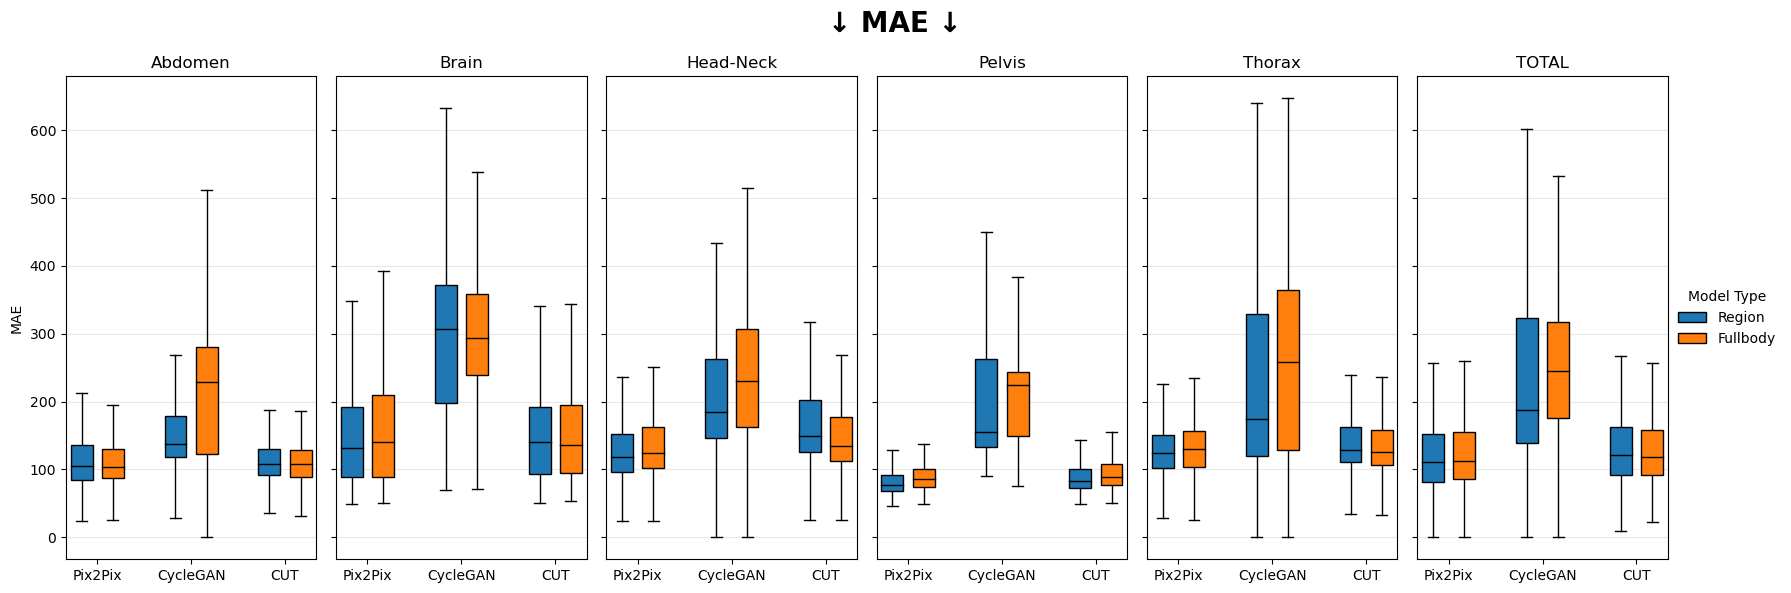

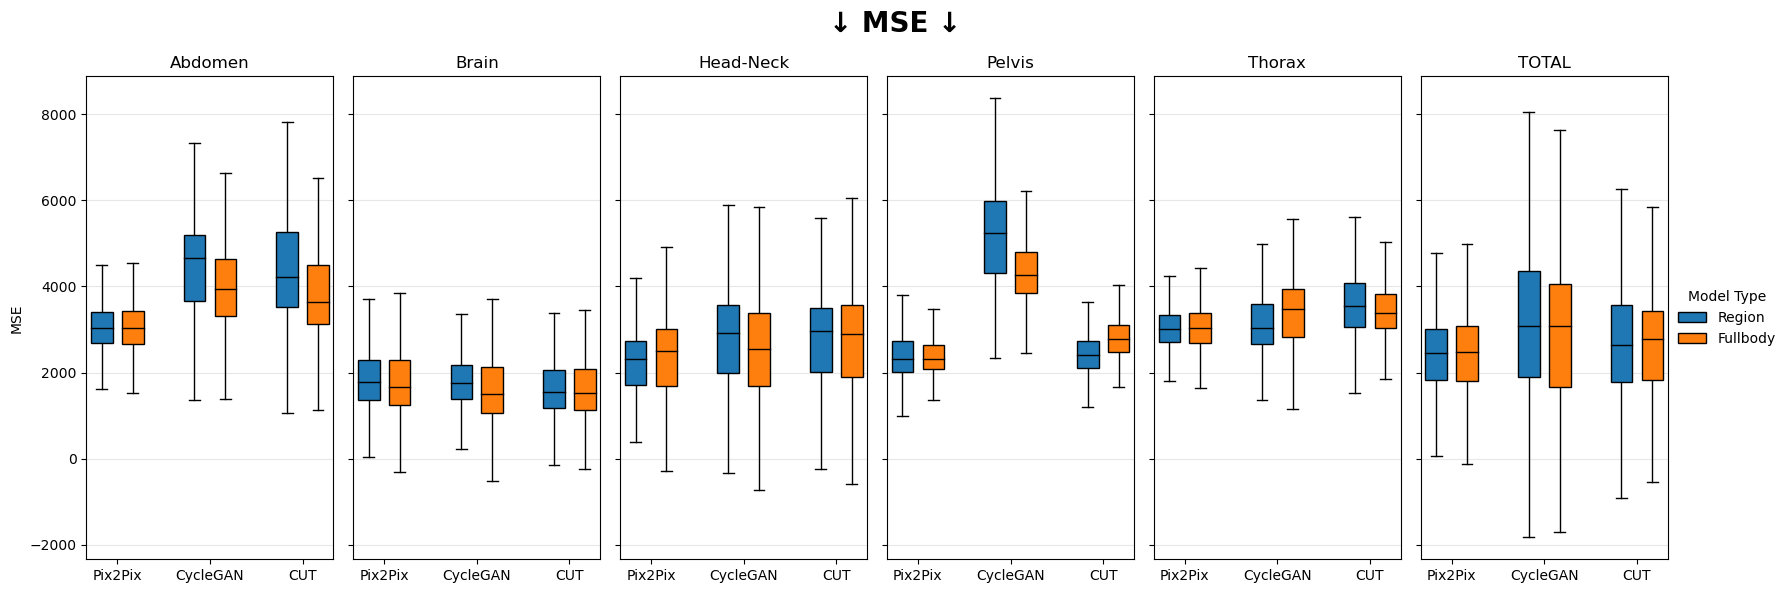

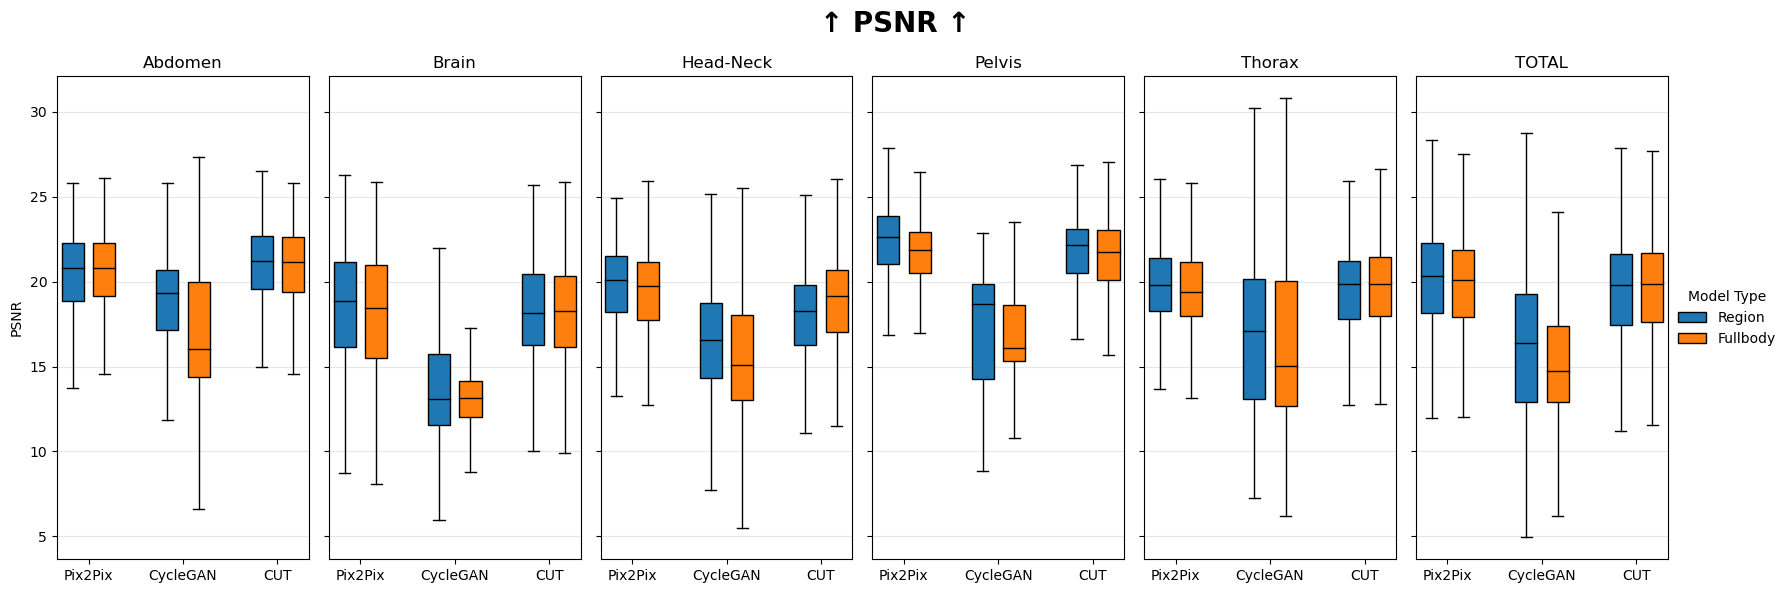

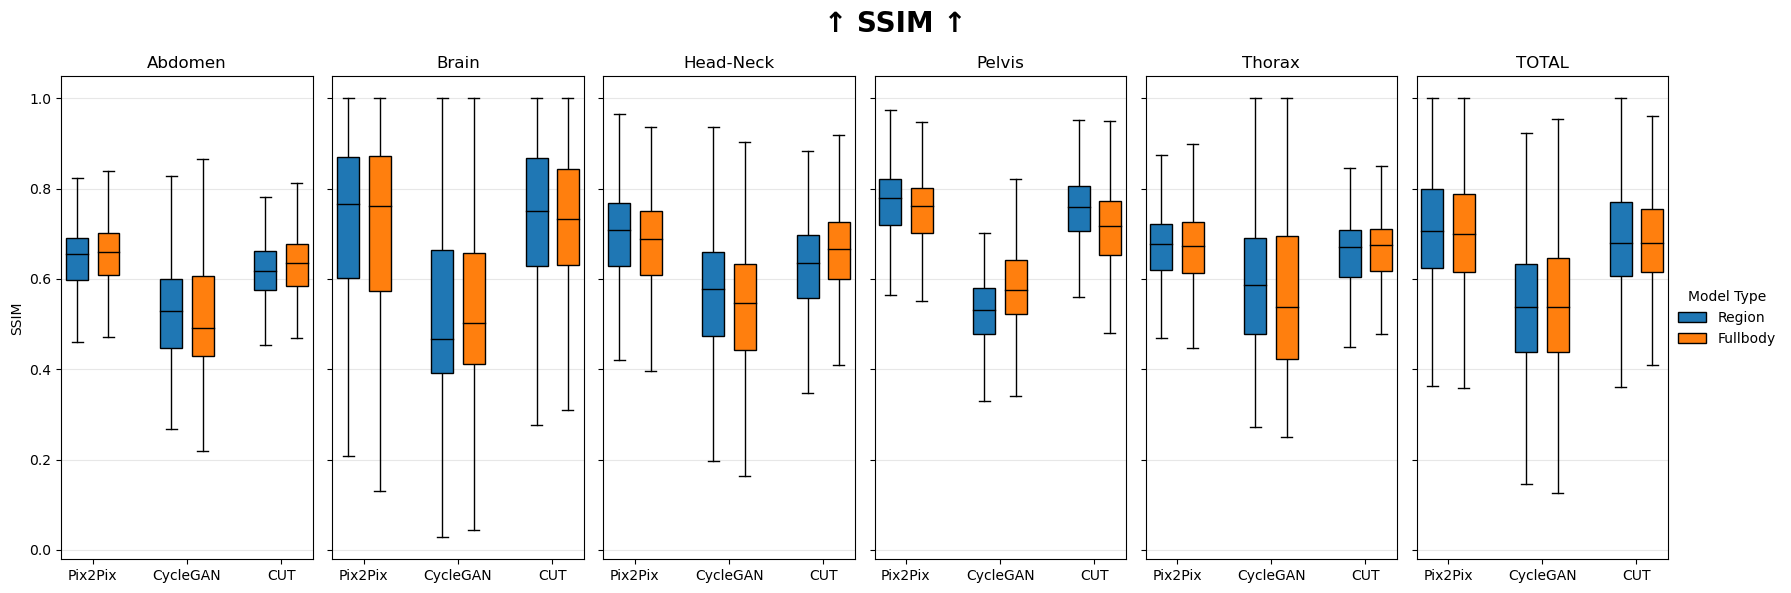

In [2]:
# Data loading
data_info_ex1_slice = pd.DataFrame(
    [
        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_headneck_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_thorax_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "pix2pix_synthrad_allregion_final/test_50/test_metrics_over_all.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_head_neck_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_thorax_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "cyclegan_allregions_final/test_50/test_metrics_over_all.csv"],
        
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_HN_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_TH_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "cut_synthrad_allregions_final/test_50/test_metrics_over_all.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex1_slice)
masked, unmasked = split_masked_unmasked(all_data)
for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
    # plot_metric_with_subplots(
    #     all_data,
    #     metric=metric,
    #     subplot_column="bodyregion",
    #     groups=["model", "region_or_fullbody"],
    #     legend_title="Model Type",
    # )
    plot_metric_with_subplots_incl_total(
        masked,
        metric=metric,
        subplot_column="bodyregion",
        groups=["model", "region_or_fullbody"],
        legend_title="Model Type",
    )

# # to produce separate plots by metric and bodyregion
# for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
#     for bodyregion in all_data["bodyregion"].unique():
#         plot_grouped_boxplots(all_data, "bodyregion", bodyregion, metric=metric, groups=["model", "region_or_fullbody"], legend_title="Separate Plots")

## Volume-level metrics

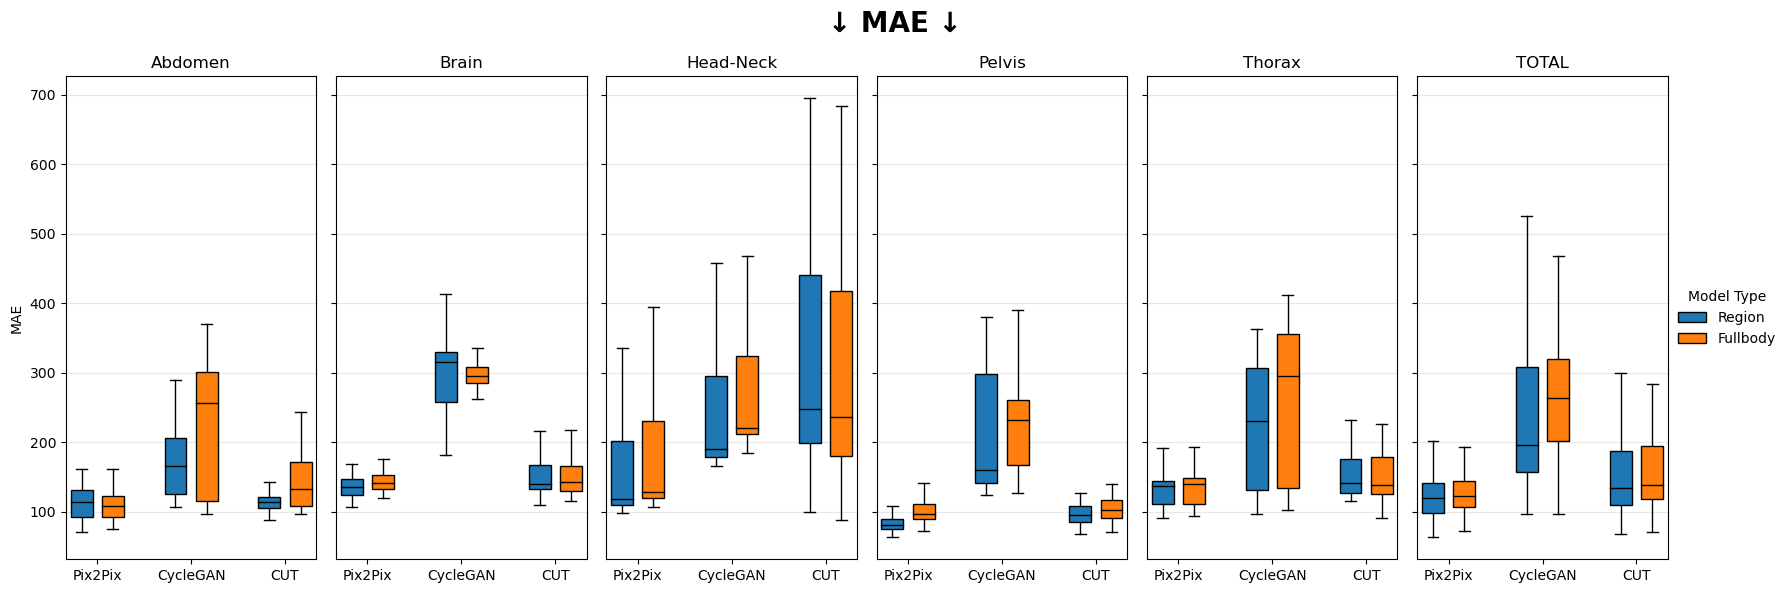

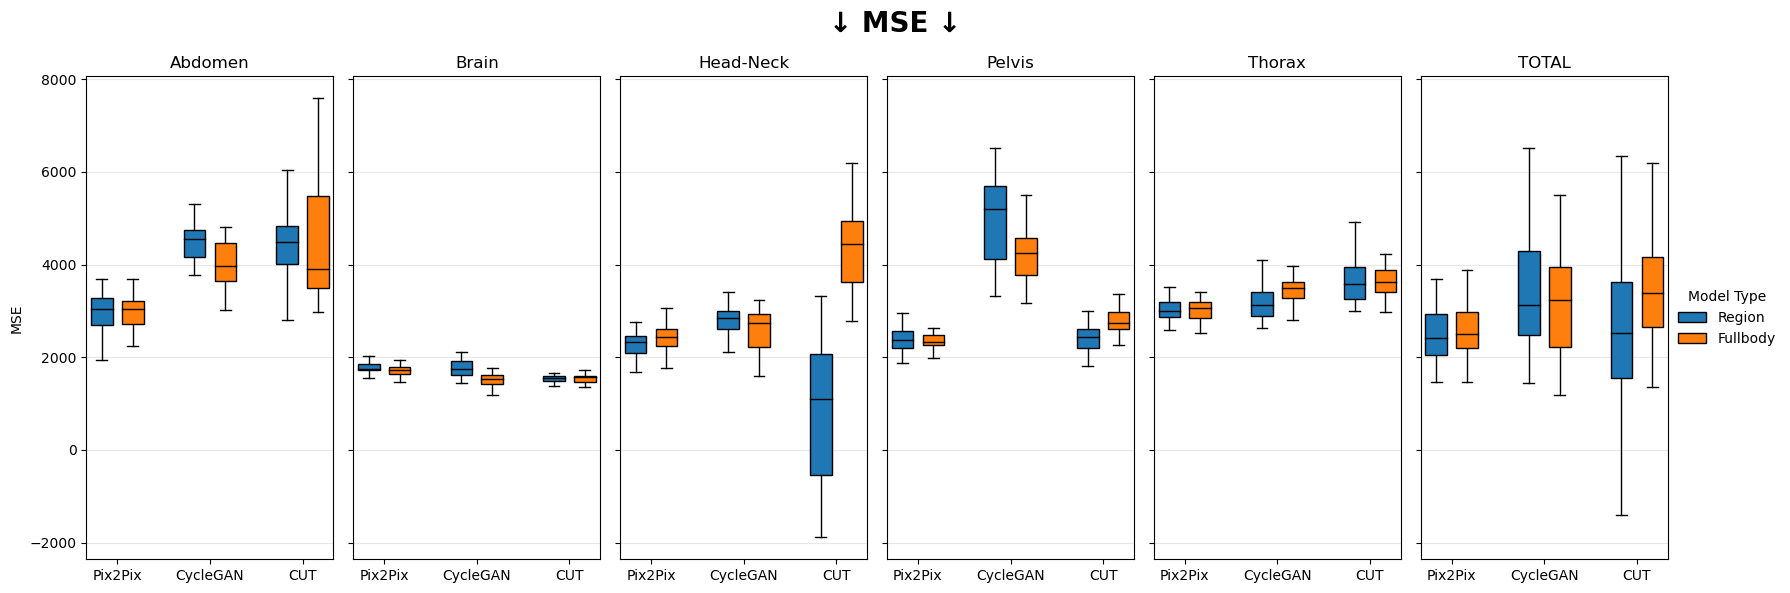

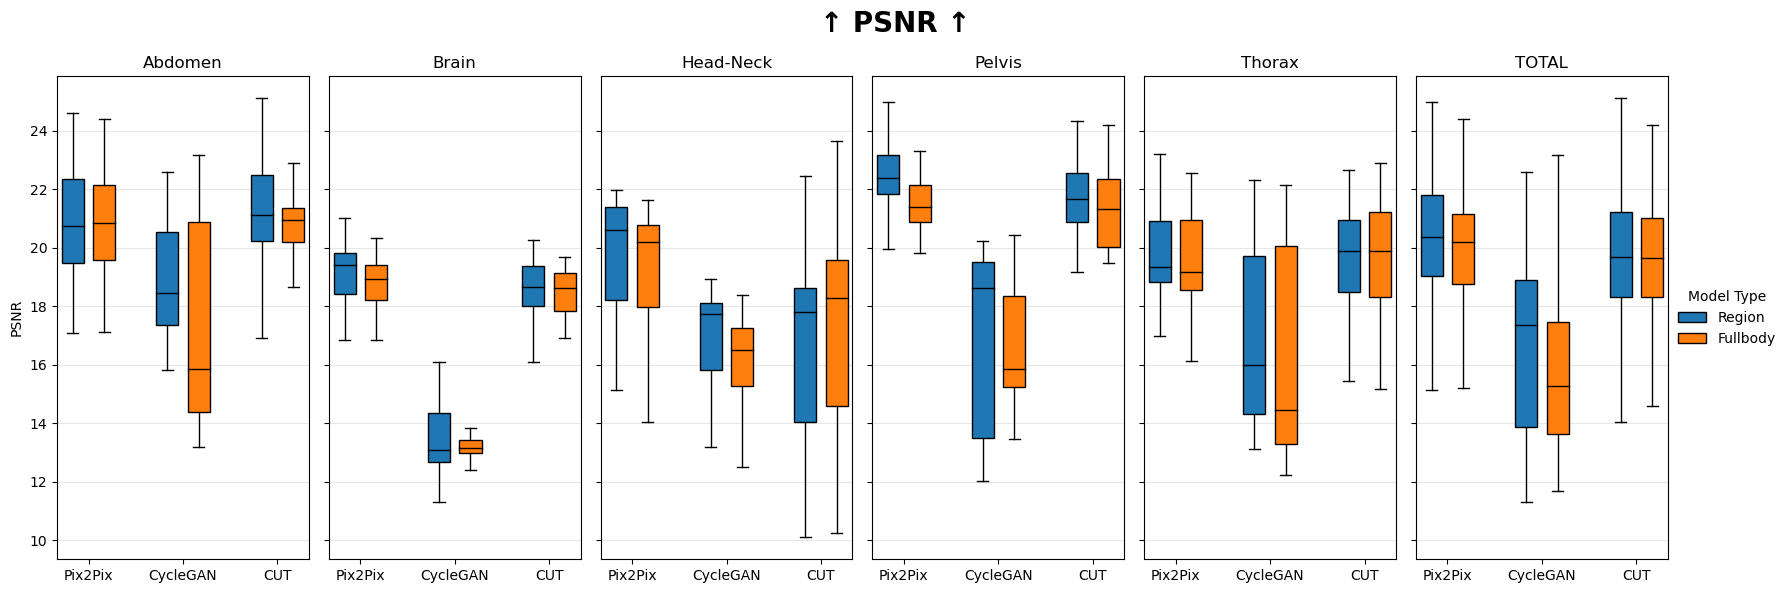

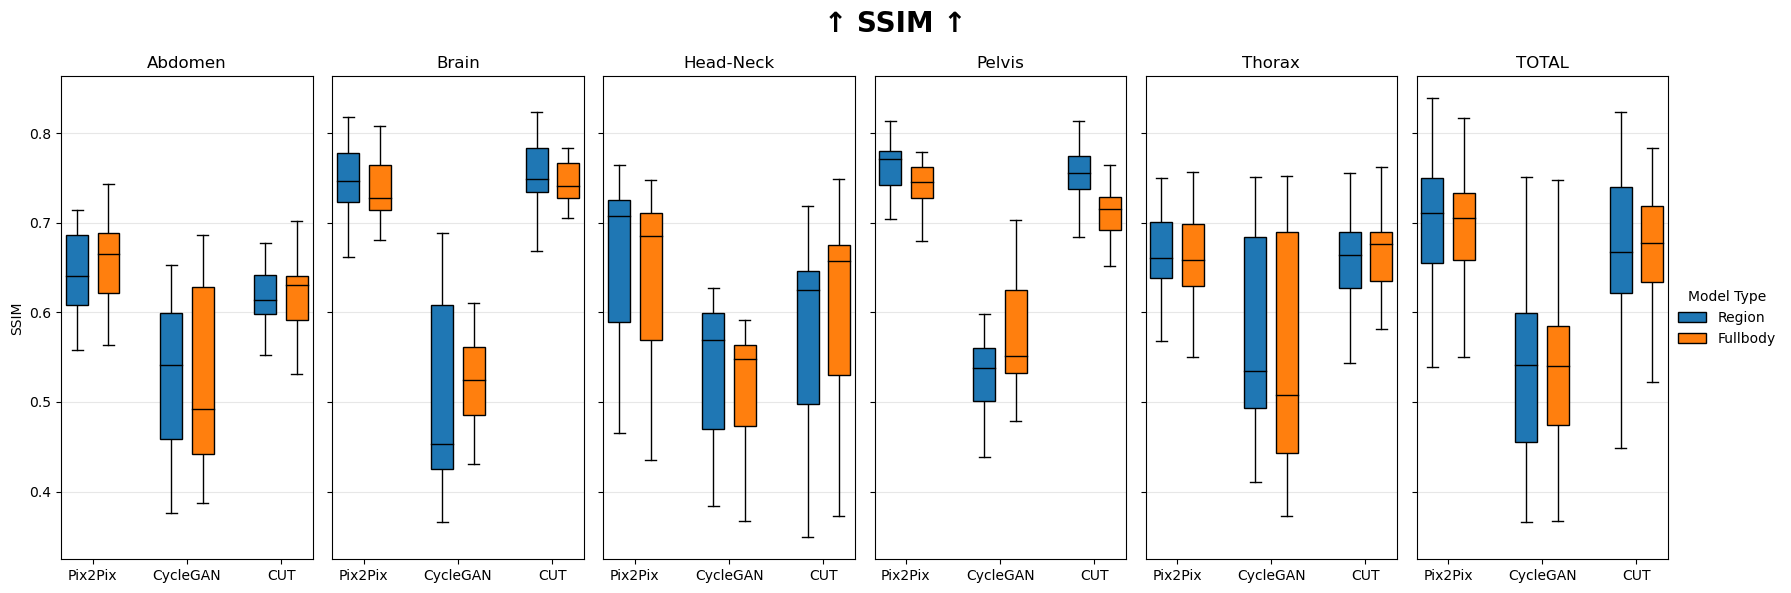

In [3]:
# Data loading
data_info_ex1_volume = pd.DataFrame(
    [
        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_headneck_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_thorax_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "pix2pix_synthrad_allregion_final/test_50/test_metrics_over_volume.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_head_neck_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cyclegan_thorax_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "cyclegan_allregions_final/test_50/test_metrics_over_volume.csv"],
        
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_brain_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_HN_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_pelvis_final/test_50/test_metrics_over_volume.csv"],
        ["Region", "Baseline", "cut_synthrad_TH_final/test_50/test_metrics_over_volume.csv"],
        ["Fullbody", "Baseline", "cut_synthrad_allregions_final/test_50/test_metrics_over_volume.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex1_volume)
masked, unmasked = split_masked_unmasked(all_data)
for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
    plot_metric_with_subplots_incl_total(
        masked,
        metric=metric,
        subplot_column="bodyregion",
        groups=["model", "region_or_fullbody"],
        legend_title="Model Type",
    )

## Synthrad Results

In [4]:
import json
from pathlib import Path
import pandas as pd

filenames = [
    "top1_testtask_KoalAI.json",
    # "top2_testtask_ImagePasNet.json",
    # "top3_testtask_BreizhCT.json",
    "cut_allregions.json",
    "cut_region_specific.json",
    "cycleGAN_allregions.json",
    "cycleGAN_region_specific.json",
    "pix2pix_allregions.json",
    "pix2pix_region_specific.json",
]

# mapping dictionary
model_map = {
   "cut":"CUT",
   "cycleGAN":"CycleGAN",
   "pix2pix":"Pix2Pix",
   "synthrad_winners":"Winners"
}
region_or_fullbody_map = {
    "allregions": "Fullbody",
    "region_specific":"Region",
    "synthrad_winners":"Region"
}

def parse_filename(fname):
    if fname.startswith("top"):
        return pd.Series({
            "filename": fname,
            "model": "synthrad_winners",
            "region_or_fullbody": "synthrad_winners",
        })
    else:
        family, mtype = fname.replace(".json", "").split("_", 1)
        return pd.Series({
            "filename": fname,
            "model": family,
            "region_or_fullbody": mtype,
        })


def load_results_and_aggregates(
    df: pd.DataFrame,
    base_dir: str = ".",
    filename_col: str = "filename",
):
    """
    Reads each JSON file referenced by df[filename_col] and returns:
      - results: one row per entry in json["results"]
      - aggregates: one row per metric-stat pair in json["aggregates"]

    Both outputs include all columns from the input df (e.g., filename, model_family, model_type),
    duplicated across the extracted rows.
    """
    base_dir = Path(base_dir)

    results_rows = []
    aggregates_rows = []

    meta_cols = [c for c in df.columns]  # keep all columns from df

    for _, row in df.iterrows():
        fname = row[filename_col]
        meta = row[meta_cols].to_dict()
        fpath = base_dir / fname

        with fpath.open("r", encoding="utf-8") as f:
            payload = json.load(f)

        # --- results (list of dicts) ---
        res_list = payload.get("results", [])
        if res_list is None:
            res_list = []
        for i, metrics in enumerate(res_list):
            out = dict(meta)
            out["result_index"] = i
            if isinstance(metrics, dict):
                out.update(metrics)
            results_rows.append(out)

        # --- aggregates (nested dict: metric -> stat -> value) ---
        aggs = payload.get("aggregates", {}) or {}
        for metric_name, stats_dict in aggs.items():
            if not isinstance(stats_dict, dict):
                continue
            for stat_name, stat_value in stats_dict.items():
                aggregates_rows.append(
                    {
                        **meta,
                        "metric": metric_name,
                        "stat": stat_name,
                        "value": stat_value,
                    }
                )

    results = pd.DataFrame(results_rows)
    aggregates = pd.DataFrame(aggregates_rows)

    # Optional: keep a consistent column order (meta first)
    if not results.empty:
        other_cols = [c for c in results.columns if c not in meta_cols]
        results = results[meta_cols + other_cols]
    if not aggregates.empty:
        aggregates = aggregates[meta_cols + ["metric", "stat", "value"]]

    aggregates = aggregates.pivot_table(
        index=['filename', 'model', 'region_or_fullbody', 'bodyregion', 'metric'],
        columns='stat', values='value').reset_index()
    
    # aggregates["mean+std"] = aggregates["mean"].round(3).astype(str) + " ± " + aggregates["std"].round(3).astype(str)
    def format_row(row):
        d = 3 if row["metric"] in ["mae_proton", "mae_photon"] else 2
        return f"{row['mean']:.{d}f} ± {row['std']:.{d}f}"

    aggregates["mean+std"] = aggregates.apply(format_row, axis=1)
    aggregates["model"] = aggregates["model"].map(model_map)
    aggregates["region_or_fullbody"] = aggregates["region_or_fullbody"].map(region_or_fullbody_map)

    results["model"] = results["model"].map(model_map)
    results["region_or_fullbody"] = results["region_or_fullbody"].map(region_or_fullbody_map)
    results = results[['filename', 'model', 'region_or_fullbody', 'bodyregion',
       'mae', 'DICE', 'HD95', 'psnr', 'ms_ssim', 'dvh_photon', 'dvh_proton',
       'mae_photon', 'mae_proton', 'gamma_pass_rate_photon',
       'gamma_pass_rate_proton']]

    return results, aggregates

# load meta information of synthrad results (filenames, categories etc.)
synthrad_results_meta = pd.DataFrame(filenames, columns=["filename"])
synthrad_results_meta[["filename", "model", "region_or_fullbody"]] = synthrad_results_meta["filename"].apply(parse_filename)
synthrad_results_meta["bodyregion"] = "allregions"

# load actual results
synthrad_results, synthrad_aggregates = load_results_and_aggregates(synthrad_results_meta, base_dir="/home/user/nschuler/fullbody-sCT/synthrad_submission/synthrad_results")


### Results table

In [5]:
# format for latex
synthrad_aggregates_table = synthrad_aggregates.pivot_table(index=["filename", "model", "region_or_fullbody", "bodyregion"], columns="metric", values="mean+std", aggfunc="first").reset_index()

In [6]:
table_img_similarity = synthrad_aggregates_table[["model", "region_or_fullbody", "mae", "psnr", "ms_ssim", "DICE", "HD95"]]
table_img_similarity.columns = ["Model", "Type", "MAE", "PSNR", "MS-SSIM", "DICE", "HD95"]

latex_img_similarity = table_img_similarity.to_latex(
    index=False,
    escape=False,
    column_format="l l c c c c c",
    caption="Image similarity metrics (mean $\\pm$ std)",
    label="tab:image_similarity"
)
print(latex_img_similarity)
table_img_similarity

\begin{table}
\centering
\caption{Image similarity metrics (mean $\pm$ std)}
\label{tab:image_similarity}
\begin{tabular}{l l c c c c c}
\toprule
   Model &     Type &            MAE &         PSNR &     MS-SSIM &        DICE &          HD95 \\
\midrule
     CUT & Fullbody & 188.57 ± 49.33 & 21.90 ± 1.81 & 0.72 ± 0.11 & 0.44 ± 0.15 & 17.89 ± 11.17 \\
     CUT &   Region & 185.90 ± 47.24 & 22.12 ± 1.81 & 0.71 ± 0.11 & 0.42 ± 0.17 & 18.41 ± 10.81 \\
CycleGAN & Fullbody & 259.77 ± 82.51 & 20.30 ± 2.70 & 0.52 ± 0.16 & 0.07 ± 0.09 & 48.09 ± 63.94 \\
CycleGAN &   Region & 221.63 ± 73.65 & 21.21 ± 2.63 & 0.58 ± 0.15 & 0.10 ± 0.11 & 51.96 ± 56.11 \\
 Pix2Pix & Fullbody & 184.91 ± 51.09 & 21.96 ± 1.74 & 0.71 ± 0.10 & 0.38 ± 0.12 & 22.15 ± 10.69 \\
 Pix2Pix &   Region & 187.40 ± 48.04 & 21.81 ± 1.63 & 0.70 ± 0.11 & 0.40 ± 0.14 & 21.55 ± 11.15 \\
 Winners &   Region &  64.81 ± 21.25 & 30.00 ± 2.76 & 0.94 ± 0.05 & 0.78 ± 0.11 &   6.01 ± 3.24 \\
\bottomrule
\end{tabular}
\end{table}



,Model,Type,MAE,PSNR,MS-SSIM,DICE,HD95
0,CUT,Fullbody,188.57 ± 49.33,21.90 ± 1.81,0.72 ± 0.11,0.44 ± 0.15,17.89 ± 11.17
1,CUT,Region,185.90 ± 47.24,22.12 ± 1.81,0.71 ± 0.11,0.42 ± 0.17,18.41 ± 10.81
2,CycleGAN,Fullbody,259.77 ± 82.51,20.30 ± 2.70,0.52 ± 0.16,0.07 ± 0.09,48.09 ± 63.94
3,CycleGAN,Region,221.63 ± 73.65,21.21 ± 2.63,0.58 ± 0.15,0.10 ± 0.11,51.96 ± 56.11
4,Pix2Pix,Fullbody,184.91 ± 51.09,21.96 ± 1.74,0.71 ± 0.10,0.38 ± 0.12,22.15 ± 10.69
5,Pix2Pix,Region,187.40 ± 48.04,21.81 ± 1.63,0.70 ± 0.11,0.40 ± 0.14,21.55 ± 11.15
6,Winners,Region,64.81 ± 21.25,30.00 ± 2.76,0.94 ± 0.05,0.78 ± 0.11,6.01 ± 3.24


In [7]:
table_dosimetric = synthrad_aggregates_table[["model", "region_or_fullbody", "gamma_pass_rate_photon", "gamma_pass_rate_proton", "dvh_photon", "dvh_proton", "mae_photon", "mae_proton"]]
table_dosimetric.columns = ["Model", "Type", r"\makecell{GPR 2mm/2\%\\(photon)}", r"\makecell{GPR 2mm/2\%\\(proton)}", r"\makecell{DVH error\\(photon)}", r"\makecell{DVH error\\(proton)}", r"\makecell{Dose MAE\\(photon)}", r"\makecell{Dose MAE\\(proton)}"]

latex_dosimetric = table_dosimetric.to_latex(
    index=False,
    escape=False,
    column_format="l l c c c c c c",
    caption="Dosimetric evaluation metrics (mean $\\pm$ std)",
    label="tab:dosimetric"
)
print(latex_dosimetric)
table_dosimetric

\begin{table}
\centering
\caption{Dosimetric evaluation metrics (mean $\pm$ std)}
\label{tab:dosimetric}
\begin{tabular}{l l c c c c c c}
\toprule
   Model &     Type & \makecell{GPR 2mm/2\%\\(photon)} & \makecell{GPR 2mm/2\%\\(proton)} & \makecell{DVH error\\(photon)} & \makecell{DVH error\\(proton)} & \makecell{Dose MAE\\(photon)} & \makecell{Dose MAE\\(proton)} \\
\midrule
     CUT & Fullbody &                     96.76 ± 6.58 &                    71.21 ± 13.38 &                    0.21 ± 0.56 &                    0.53 ± 1.25 &                 0.010 ± 0.013 &                 0.040 ± 0.068 \\
     CUT &   Region &                     96.18 ± 7.82 &                    70.18 ± 11.70 &                    0.22 ± 0.56 &                    0.75 ± 3.86 &                 0.012 ± 0.016 &                 0.042 ± 0.068 \\
CycleGAN & Fullbody &                    78.42 ± 22.73 &                    54.76 ± 17.85 &                    0.41 ± 0.62 &                    1.20 ± 6.41 &                 0

,Model,Type,\makecell{GPR 2mm/2\%\\(photon)},\makecell{GPR 2mm/2\%\\(proton)},\makecell{DVH error\\(photon)},\makecell{DVH error\\(proton)},\makecell{Dose MAE\\(photon)},\makecell{Dose MAE\\(proton)}
0,CUT,Fullbody,96.76 ± 6.58,71.21 ± 13.38,0.21 ± 0.56,0.53 ± 1.25,0.010 ± 0.013,0.040 ± 0.068
1,CUT,Region,96.18 ± 7.82,70.18 ± 11.70,0.22 ± 0.56,0.75 ± 3.86,0.012 ± 0.016,0.042 ± 0.068
2,CycleGAN,Fullbody,78.42 ± 22.73,54.76 ± 17.85,0.41 ± 0.62,1.20 ± 6.41,0.045 ± 0.117,0.131 ± 0.267
3,CycleGAN,Region,83.20 ± 22.53,59.69 ± 16.81,0.38 ± 0.62,1.02 ± 4.31,0.036 ± 0.098,0.125 ± 0.268
4,Pix2Pix,Fullbody,95.36 ± 8.61,69.23 ± 12.84,0.22 ± 0.56,4.82 ± 64.01,0.012 ± 0.016,0.040 ± 0.029
5,Pix2Pix,Region,94.63 ± 8.34,70.03 ± 13.50,0.21 ± 0.56,11.96 ± 168.18,0.013 ± 0.015,0.044 ± 0.071
6,Winners,Region,98.33 ± 5.41,84.04 ± 10.54,0.19 ± 0.56,0.35 ± 1.18,0.006 ± 0.009,0.024 ± 0.067


### Results plots

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Optional, Any, List, Sequence, Dict

def plot_multiple_metrics_with_subplots(
    df: pd.DataFrame,
    metrics: Sequence[str],
    groups: List[str],
    *,
    # optional filtering (e.g., lock to preprocessing="Baseline")
    filter_column: Optional[str] = None,
    filter_value: Optional[Any] = None,
    # layout/styling
    figsize_per_subplot: tuple = (4, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
    metric_titles: Optional[Dict[str, str]] = None,
    sharey: bool = False,
):
    """
    One figure with one subplot per metric (no split by bodyregion).
    Each subplot shows grouped boxplots based on `groups` (len 1 or 2).

    Parameters
    ----------
    df : pd.DataFrame
    metrics : list/tuple of metric column names
    groups : 1 or 2 columns to group boxplots (same semantics as your existing functions)
    filter_column/filter_value : optional filter applied before plotting
    figsize_per_subplot : (width, height) per metric subplot
    showfliers : whether to show outliers
    title : overall figure title
    legend_title : title for legend (defaults to groups[1] if 2 groups)
    metric_titles : mapping metric -> display title (optional)
    sharey : if True, share y-axis across metrics (usually False since scales differ)
    """
    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    for m in metrics:
        if m not in df.columns:
            raise KeyError(f"metric {m!r} not in df.columns")

    dff = df.copy()

    if filter_column is not None:
        if filter_column not in dff.columns:
            raise KeyError(f"filter_column={filter_column} not in df.columns")
        dff = dff[dff[filter_column] == filter_value].copy()

    # drop rows missing any plotted metric (keeps comparisons consistent)
    dff = dff.dropna(subset=list(metrics))
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")

    n = len(metrics)
    fig, axes = plt.subplots(
        1, n,
        figsize=(figsize_per_subplot[0] * n, figsize_per_subplot[1]),
        sharey=sharey,
    )
    if n == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    # consistent ordering across all metric subplots
    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))
        legend_handles = None
    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))
        colors = {k: (cycle[i % len(cycle)] if cycle else f"C{i}") for i, k in enumerate(order2)}
        legend_handles = [Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2]

    # default nice titles if you want arrows
    # default_metric_titles = {"MAE": "↓ MAE ↓", "MSE": "↓ MSE ↓", "PSNR": "↑ PSNR ↑", "SSIM": "↑ SSIM ↑"}
    default_metric_titles = {}
    metric_titles = metric_titles or {}

    for ax, metric in zip(axes, metrics):
        if len(groups) == 1:
            data = [dff.loc[dff[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)
            ax.set_xlabel(g1)

        else:
            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.set_xlabel(g1)

        ax.set_title(metric_titles.get(metric, default_metric_titles.get(metric, metric)))
        ax.grid(True, axis="y", alpha=0.3)

    # y labels: either per axis or just the first one
    if sharey:
        axes[0].set_ylabel("Value")
    else:
        for ax, metric in zip(axes, metrics):
            ax.set_ylabel(metric)

    # one legend for whole figure (right side), only when groups==2
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )
        plt.tight_layout(rect=(0, 0, 0.88, 1))
    else:
        plt.tight_layout()

    if title is not None:
        fig.suptitle(title, fontsize=16, fontweight="bold")
        # if you set a suptitle after tight_layout, give it some room:
        plt.subplots_adjust(top=0.85)

    plt.show()


In [9]:
synthrad_results.columns = ['filename', 'model', 'region_or_fullbody', 'bodyregion',
       'MAE', 'DICE', 'HD95', 'PSNR', 'MS-SSIM', 'DVH error (photon)', 'DVH error (proton)',
       'Dose MAE (photon)', 'Dose MAE (proton)', 'GPR 2mm/2% (photon)',
       'GPR 2mm/2% (proton)']

order = ["Winners", "CUT", "Pix2Pix", "CycleGAN"]

# order for plots
synthrad_results["model"] = pd.Categorical(synthrad_results["model"], categories=order, ordered=True)
synthrad_results = synthrad_results.sort_values("model")
synthrad_results["model"] = synthrad_results["model"].astype(str)

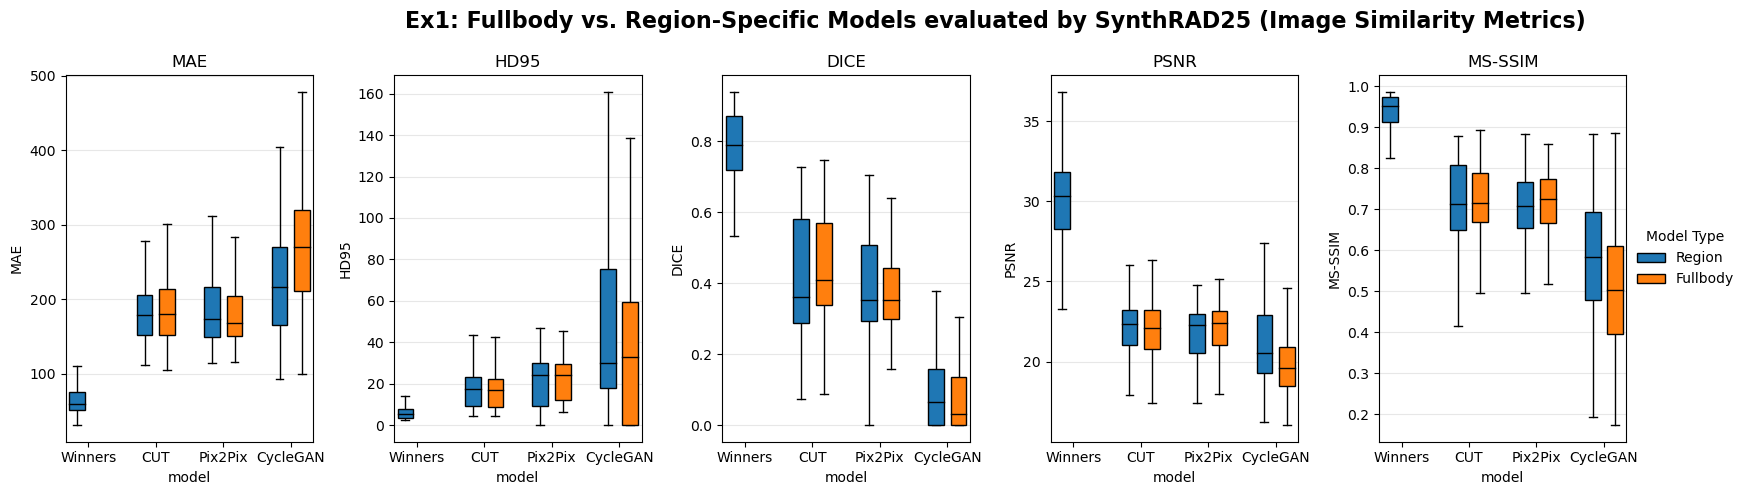

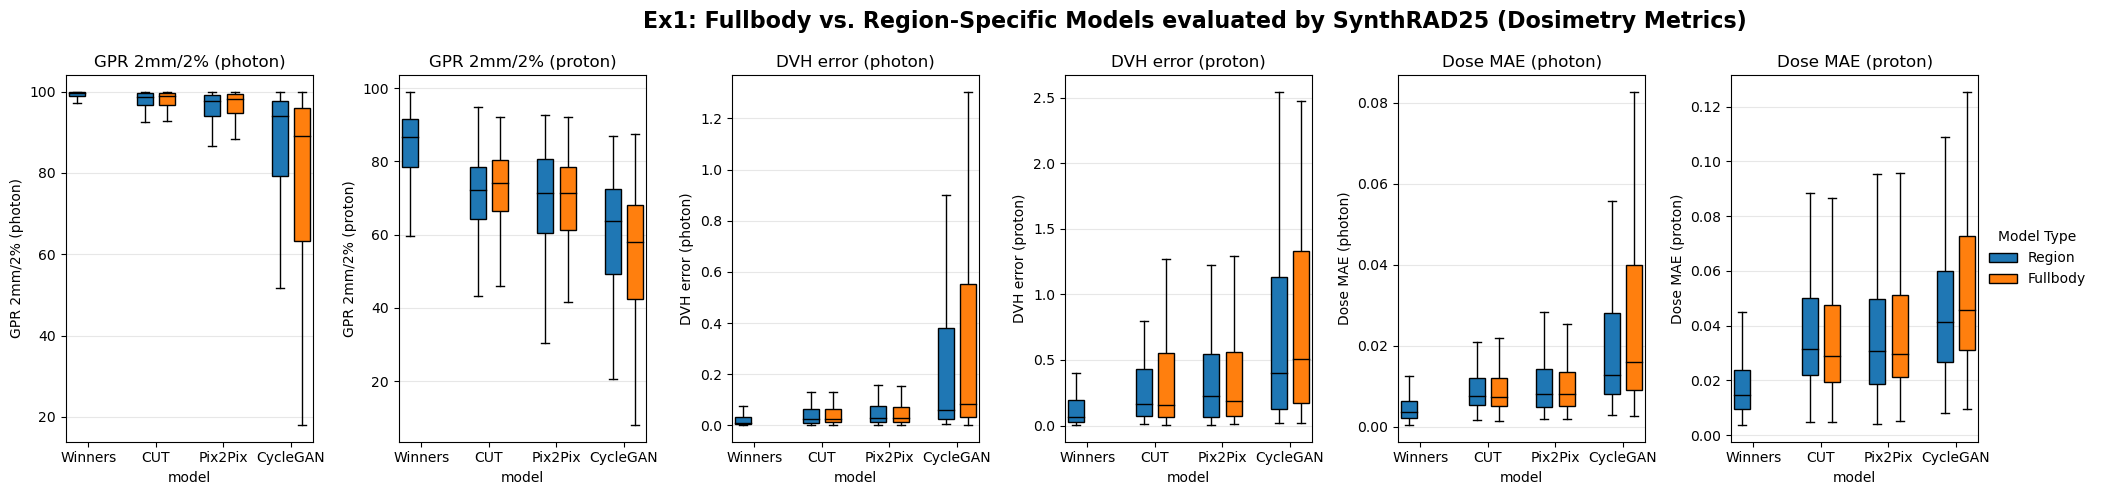

In [10]:
plot_multiple_metrics_with_subplots(
    synthrad_results,
    metrics=['MAE', 'HD95', 'DICE', 'PSNR', 'MS-SSIM'],
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    title="Ex1: Fullbody vs. Region-Specific Models evaluated by SynthRAD25 (Image Similarity Metrics)",
)

plot_multiple_metrics_with_subplots(
    synthrad_results,
    metrics=['GPR 2mm/2% (photon)', 'GPR 2mm/2% (proton)', 'DVH error (photon)', 'DVH error (proton)', 'Dose MAE (photon)', 'Dose MAE (proton)'],
    groups=["model", "region_or_fullbody"],
    legend_title="Model Type",
    title="Ex1: Fullbody vs. Region-Specific Models evaluated by SynthRAD25 (Dosimetry Metrics)",
)


# Experiment 2

In [11]:
# Data loading
data_info_ex2 = pd.DataFrame(
    [
        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_all.csv"],
        
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex2)
plot_grouped_boxplots(all_data, "model", "Pix2Pix", metric="MAE", groups=["preprocessing"])
plot_grouped_boxplots(all_data, "bodyregion", "AB", metric="MAE", groups=["model", "preprocessing"], legend_title="Preprocessing")


# not tested
plot_metric_with_subplots(
    all_data,
    metric="MAE",
    subplot_column="preprocessing",
    groups=["model"],
)

KeyError: 'metric=MAE not in df.columns'